<a href="https://colab.research.google.com/github/PreethiR091/ML-Lab/blob/main/Preethi_R_24BAD091_ML_Ex_no_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SCENARIO 1 – K-NEAREST NEIGHBORS (KNN)



Problem Statement

Predict whether a tumor is benign or malignant based on medical measurements.



Dataset (Kaggle – Public)

Breast Cancer Dataset

Dataset Link: https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset


Preethi R 24BAD091

Accuracy: 0.9298245614035088

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        71
           1       0.91      0.91      0.91        43

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



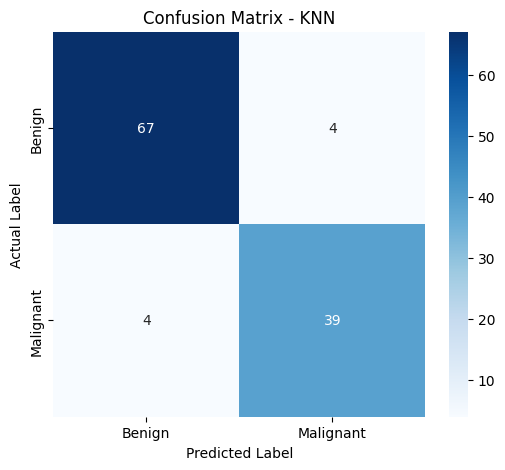

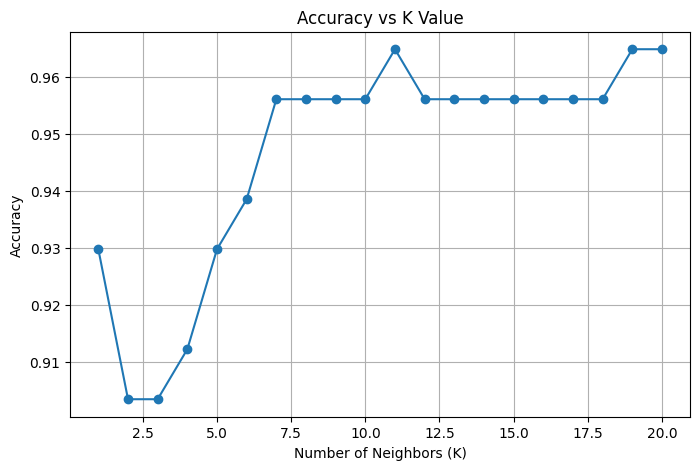

Best K value: 11


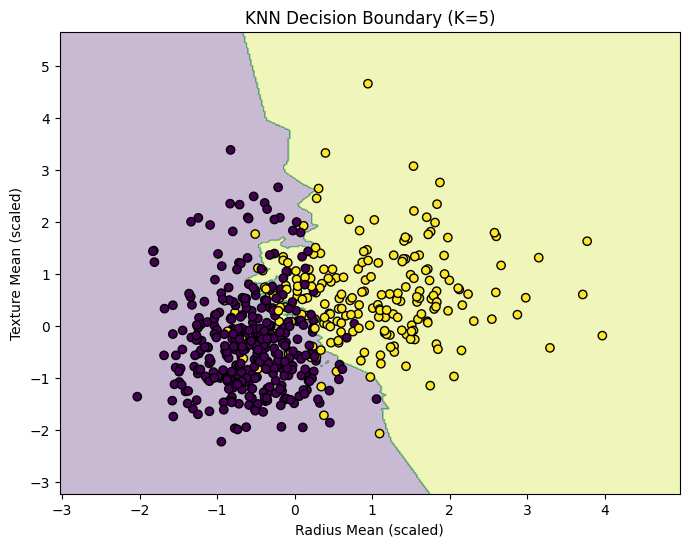

In [ ]:
print("Preethi R 24BAD091\n")
# KNN Classification – Breast Cancer Dataset

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load Dataset
df = pd.read_csv("breast-cancer.csv")   # Change path if needed

# 3. Encode Target (M=1, B=0)
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

# 4. Select Features (as per your dataset)
X = df[['radius_mean',
        'texture_mean',
        'perimeter_mean',
        'area_mean',
        'smoothness_mean']]

y = df['diagnosis']

# 5. Feature Scaling (IMPORTANT for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 7. Train Initial Model (K=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 8. Prediction
y_pred = knn.predict(X_test)

# 9. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - KNN")
plt.show()

# Accuracy vs K Plot

accuracies = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_k))

plt.figure(figsize=(8,5))
plt.plot(range(1, 21), accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K Value")
plt.grid(True)
plt.show()

best_k = np.argmax(accuracies) + 1
print("Best K value:", best_k)

# Decision Boundary (2 Features)

# Use only two features for visualization
X2 = df[['radius_mean', 'texture_mean']]
y2 = df['diagnosis']

# Scale
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# Train-Test Split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42
)

# Train KNN
knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train2, y_train2)

# Create Mesh Grid
x_min, x_max = X2_scaled[:, 0].min() - 1, X2_scaled[:, 0].max() + 1
y_min, y_max = X2_scaled[:, 1].min() - 1, X2_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict for grid points
Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot Decision Boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2_scaled[:, 0], X2_scaled[:, 1],
            c=y2, edgecolor='k')
plt.xlabel("Radius Mean (scaled)")
plt.ylabel("Texture Mean (scaled)")
plt.title("KNN Decision Boundary (K=5)")
plt.show()

Step 1: Import Libraries

    First, required libraries are imported.
    Pandas and NumPy are used for handling data and numerical operations.
    Matplotlib and Seaborn are used to visualize graphs.
    Scikit-learn libraries are used for machine learning tasks like data splitting, scaling, building the KNN model, and evaluating performance.

Step 2: Load the Dataset

    The Breast Cancer dataset is loaded from a CSV file into a dataframe.
    This dataset contains various tumor features and a diagnosis column indicating whether the tumor is Malignant (M) or Benign (B).

Step 3: Encode the Target Variable

    The diagnosis column contains categorical values (M and B).
    Since machine learning models require numerical values, they are converted into numbers:
    Malignant → 1
    Benign → 0

Step 4: Select Features

    A few important tumor features are selected as input variables:

    radius_mean
    texture_mean
    perimeter_mean
    area_mean
    smoothness_mean

    These features help the model identify whether the tumor is cancerous or not.

Step 5: Feature Scaling

    Feature scaling is applied using standardization.
    This step converts all feature values into a similar scale (mean = 0, standard deviation = 1).
    Scaling is important because KNN uses distance calculation, and features with larger values could dominate the results.

Step 6: Train-Test Split

    The dataset is divided into two parts:
    Training data (80%) to train the model
    Testing data (20%) to evaluate the model
    This helps test how well the model performs on unseen data.

Step 7: Train the KNN Model

    A K-Nearest Neighbors classifier is created with K = 5.
    The model learns from the training data by storing the feature patterns and class labels.

Step 8: Make Predictions

    The trained model is used to predict the diagnosis for the test dataset.
    The predictions are then compared with the actual values.

Step 9: Evaluate the Model

    The model performance is evaluated using:
    Accuracy Score – percentage of correct predictions.
    Classification Report – shows precision, recall, and F1-score for each class.
    A confusion matrix is also generated and visualized using a heatmap to show correct and incorrect classifications.

Step 10: Accuracy vs K Graph

    Different K values from 1 to 20 are tested to see which value gives the best accuracy.
    A graph is plotted between K value and Accuracy to identify the optimal K for the model.

Step 11: Decision Boundary Visualization

    For visualization, only two features (radius_mean and texture_mean) are used.
    A mesh grid is created and the model predicts the class for each point.
    A graph is plotted showing how the KNN model separates benign and malignant tumors in the feature space.

SCENARIO 2 – DECISION TREE CLASSIFIER



Problem Statement

Predict whether a loan application should be approved or rejected.



Dataset (Public / Standard Dataset)

Loan Prediction Dataset

Dataset Link: https://www.kaggle.com/datasets/ninzaami/loan-predication


Preethi R 24BAD091

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  


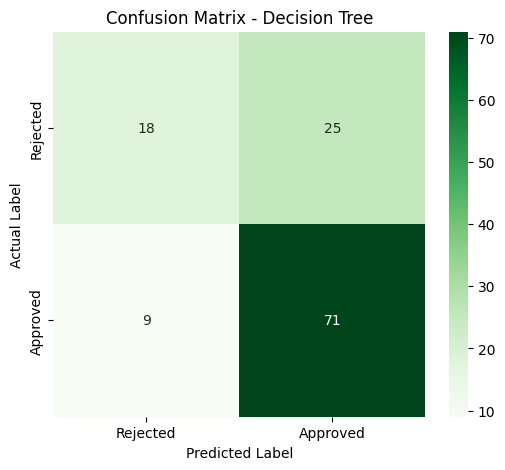

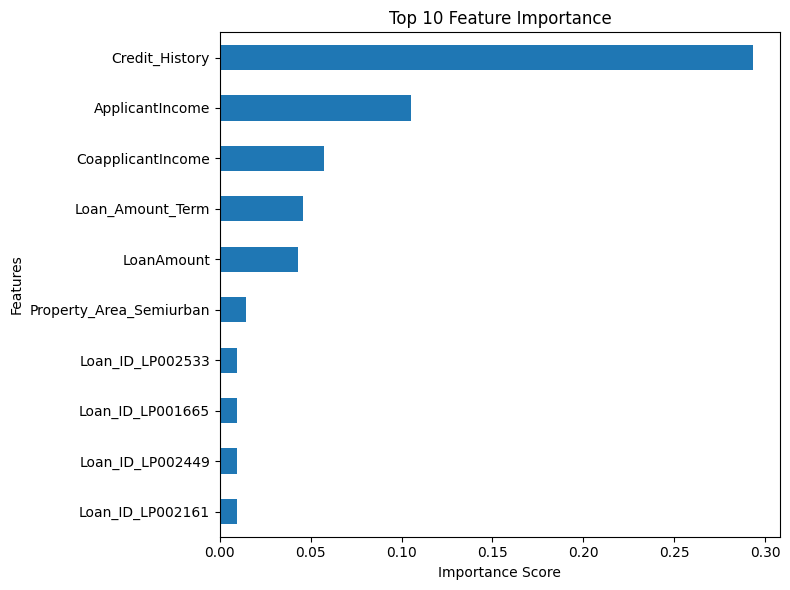

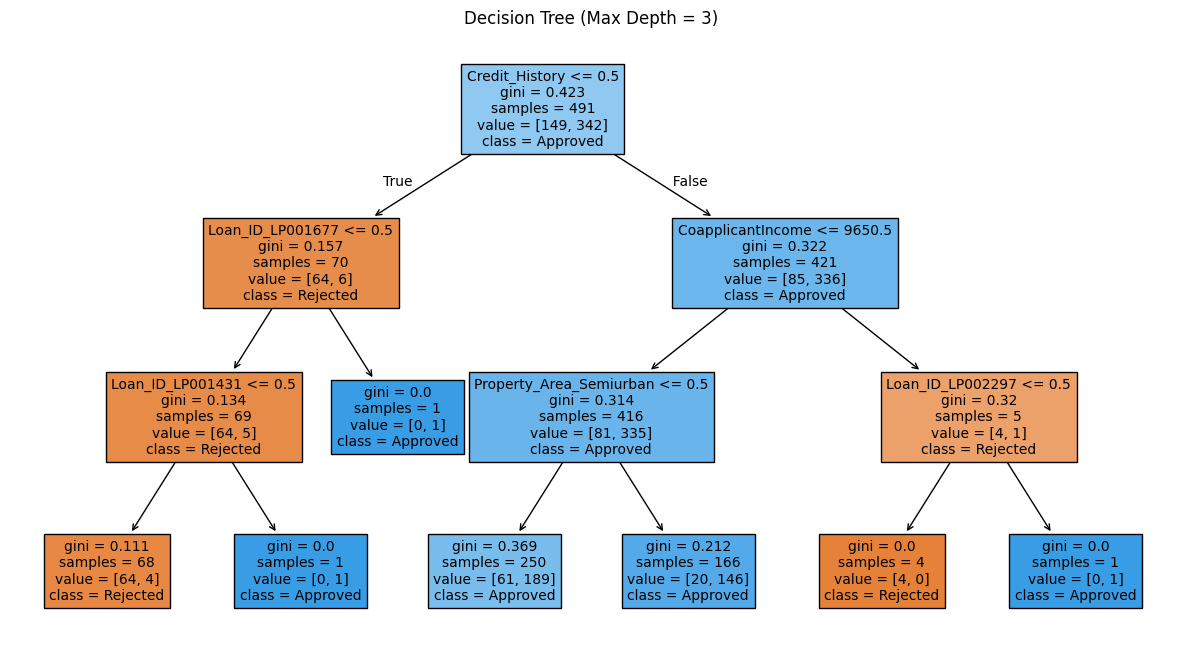

Shallow Tree Accuracy: 0.7886178861788617
Deep Tree Accuracy: 0.7479674796747967


In [ ]:
print("Preethi R 24BAD091\n")
# Decision Tree Classification – Loan Prediction

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load Dataset
df = pd.read_csv("train_u6lujuX_CVtuZ9i (1).csv")   # Change path if needed

# 3. Data Inspection
print(df.head())
print(df.info())
print(df.isnull().sum())

# 4. Handle Missing Values (Mode for categorical)
df.fillna(df.mode().iloc[0], inplace=True)

# 5. Convert Target Column
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# 6. Encode Categorical Variables
df = pd.get_dummies(df, drop_first=True)

# 7. Define Features & Target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# 8. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 9. Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# 10. Prediction
y_pred = dt.predict(X_test)

# 11. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Rejected","Approved"],
            yticklabels=["Rejected","Approved"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# Feature Importance (Top 10 Only)

importances = pd.Series(dt.feature_importances_, index=X.columns)

# Sort in descending order
importances = importances.sort_values(ascending=False)

# Select Top 10
top_features = importances.head(10)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()
# Tree Structure Plot

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Plot clean tree
plt.figure(figsize=(15,8))
tree.plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    filled=True,
    fontsize=10
)
plt.title("Decision Tree (Max Depth = 3)")
plt.show()
# Shallow vs Deep Tree Comparison (Overfitting Check)

dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_deep = DecisionTreeClassifier(max_depth=10, random_state=42)

dt_shallow.fit(X_train, y_train)
dt_deep.fit(X_train, y_train)

print("Shallow Tree Accuracy:",
      accuracy_score(y_test, dt_shallow.predict(X_test)))

print("Deep Tree Accuracy:",
      accuracy_score(y_test, dt_deep.predict(X_test)))

Step 1: Import Libraries

    Import Pandas to load and manipulate the dataset.
    Import NumPy for numerical operations.
    Import Matplotlib and Seaborn for data visualization and plotting graphs.
    Import Scikit-learn libraries for machine learning tasks such as:
    splitting the dataset,
    building the Decision Tree model,
    visualizing the tree,
    evaluating the model performance.

Step 2: Load the Dataset

    The Loan Prediction dataset is loaded from a CSV file.
    Each row represents a loan application record.
    The dataset contains information such as:
      applicant income,
      loan amount,
      credit history,
      marital status,
      education level.
    The target column Loan_Status indicates whether the loan is:
      Approved (Y)
      Rejected (N).

Step 3: Data Inspection

    The first few rows of the dataset are displayed.
    Information about the dataset is checked, including:
      column names,
      data types,
      number of entries.
    Missing values in each column are also identified.

Step 4: Handle Missing Values

    Some columns may contain missing values.
    Missing values are filled using the mode (most frequent value).
    This method is suitable for categorical data.

Step 5: Convert Target Column

    The Loan_Status column contains categorical values (Y and N).
    These values are converted into numerical form:
      Y → 1 (Loan Approved)
      N → 0 (Loan Rejected)
    This conversion allows the machine learning model to process the target variable.

Step 6: Encode Categorical Variables

    Many columns in the dataset are categorical (e.g., Gender, Education, Property Area).
    These columns are converted into numerical variables using one-hot encoding.
    This process creates new binary columns representing each category.

Step 7: Define Features and Target

    The dataset is divided into:
      Features (X) → input variables used for prediction.
      Target (y) → the Loan_Status column.
    The target column is removed from the feature set.

Step 8: Train-Test Split

    The dataset is split into two parts:
      Training data (80%)
      Testing data (20%)
    The training data is used to train the model.
    The testing data is used to evaluate the model performance.

Step 9: Train the Decision Tree Model

    A Decision Tree Classifier is created.
    The model learns patterns from the training dataset.
    It creates decision rules based on features such as income, credit history, and loan amount.

Step 10: Prediction

    The trained model is used to predict loan status for the test dataset.
    The model predicts whether a loan will be:
      Approved
      Rejected

Step 11: Model Evaluation

    The performance of the model is evaluated using:
      Accuracy Score → percentage of correct predictions.
      Classification Report → shows precision, recall, and F1-score
    A Confusion Matrix is generated to compare:
      actual values,
      predicted values
    The confusion matrix is visualized using a heatmap.

Step 12: Feature Importance

    The Decision Tree identifies which features are most important for prediction.
    Each feature is given an importance score.
    The top 10 important features are selected.
    A horizontal bar chart is plotted to visualize these important features.

Step 13: Tree Structure Visualization

    A Decision Tree diagram is plotted to show how decisions are made.
    The tree uses rules based on features to split the data.
    The depth of the tree is limited to 3 levels to keep it simple and easy to understand.

Step 14: Shallow vs Deep Tree Comparison

    Two models are created:
      Shallow Tree (max_depth = 3)
      Deep Tree (max_depth = 10)
    Both models are trained and their accuracy scores are compared.
    This comparison helps identify overfitting:
      shallow trees generalize better,
      deep trees may memorize training data.